In [ ]:
!pip install gymnasium keras-rl2 tensorflow

In [13]:
import numpy as np
import gymnasium as gym
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding
from tensorflow.keras.optimizers.legacy import Adam

from rl.agents import DQNAgent
from rl.memory import SequentialMemory
from rl.policy import EpsGreedyQPolicy, BoltzmannQPolicy

print(tf.__version__)
print("Imports working")

2.15.0
Imports working


In [8]:
class GymnasiumToGymWrapper:
    def __init__(self, env):
        self.env = env
        self.action_space = env.action_space
        self.observation_space = env.observation_space
        self.metadata = env.metadata
        self.reward_range = env.reward_range
        self.spec = env.spec

    def reset(self):
        observation, info = self.env.reset()
        return observation

    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return observation, reward, done, info

    def render(self, mode="human"):
        return self.env.render()

    def close(self):
        self.env.close()

In [10]:
base_env = gym.make("CliffWalking-v0")
env = GymnasiumToGymWrapper(base_env)

nb_states = env.observation_space.n
nb_actions = env.action_space.n

print("Number of states:", nb_states)
print("Number of actions:", nb_actions)

Number of states: 48
Number of actions: 4


In [11]:
def build_model(nb_states, nb_actions):
    model = Sequential()
    model.add(Embedding(input_dim=nb_states, output_dim=16, input_length=1))
    model.add(Flatten())
    model.add(Dense(24, activation="relu"))
    model.add(Dense(24, activation="relu"))
    model.add(Dense(nb_actions, activation="linear"))
    return model

In [14]:
model_eps = build_model(nb_states, nb_actions)

memory_eps = SequentialMemory(limit=50000, window_length=1)

policy_eps = EpsGreedyQPolicy(eps=0.1)

dqn_eps = DQNAgent(
    model=model_eps,
    nb_actions=nb_actions,
    memory=memory_eps,
    nb_steps_warmup=100,
    target_model_update=1e-2,
    policy=policy_eps
)

dqn_eps.compile(Adam(learning_rate=1e-3), metrics=["mae"])

model_eps.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 1, 16)             768       
                                                                 
 flatten_1 (Flatten)         (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 24)                408       
                                                                 
 dense_4 (Dense)             (None, 24)                600       
                                                                 
 dense_5 (Dense)             (None, 4)                 100       
                                                                 
Total params: 1876 (7.33 KB)
Trainable params: 1876 (7.33 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
history_eps = dqn_eps.fit(
    env,
    nb_steps=10000,
    visualize=False,
    verbose=1
)

Training for 10000 steps ...
Interval 1 (0 steps performed)


    1/10000 [..............................] - ETA: 13:20 - reward: -1.0000

C:\Users\sbasd\PycharmProjects\JupyterProject\.venv1\lib\site-packages\keras\src\engine\training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


10000/10000 [==============================] - 27s 3ms/step - reward: -2.0494
done, took 26.764 seconds


In [16]:
scores_eps = dqn_eps.test(
    env,
    nb_episodes=20,
    visualize=False
)

eps_rewards = scores_eps.history["episode_reward"]

print("Epsilon-Greedy Rewards:", eps_rewards)
print("Epsilon-Greedy Mean Reward:", np.mean(eps_rewards))

Testing for 20 episodes ...
Episode 1: reward: -13.000, steps: 13
Episode 2: reward: -13.000, steps: 13
Episode 3: reward: -13.000, steps: 13
Episode 4: reward: -13.000, steps: 13
Episode 5: reward: -13.000, steps: 13
Episode 6: reward: -13.000, steps: 13
Episode 7: reward: -13.000, steps: 13
Episode 8: reward: -13.000, steps: 13
Episode 9: reward: -13.000, steps: 13
Episode 10: reward: -13.000, steps: 13
Episode 11: reward: -13.000, steps: 13
Episode 12: reward: -13.000, steps: 13
Episode 13: reward: -13.000, steps: 13
Episode 14: reward: -13.000, steps: 13
Episode 15: reward: -13.000, steps: 13
Episode 16: reward: -13.000, steps: 13
Episode 17: reward: -13.000, steps: 13
Episode 18: reward: -13.000, steps: 13
Episode 19: reward: -13.000, steps: 13
Episode 20: reward: -13.000, steps: 13
Epsilon-Greedy Rewards: [-13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0, -13.0]
Epsilon-Greedy Mean Reward: -13.0


In [19]:
base_env_boltz = gym.make("CliffWalking-v0")
env_boltz = GymnasiumToGymWrapper(base_env_boltz)

In [20]:
model_boltz = build_model(nb_states, nb_actions)

memory_boltz = SequentialMemory(limit=50000, window_length=1)

policy_boltz = BoltzmannQPolicy(tau=1.0)

dqn_boltz = DQNAgent(
    model=model_boltz,
    nb_actions=nb_actions,
    memory=memory_boltz,
    nb_steps_warmup=100,
    target_model_update=1e-2,
    policy=policy_boltz
)

dqn_boltz.compile(Adam(learning_rate=1e-3), metrics=["mae"])

model_boltz.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 1, 16)             768       
                                                                 
 flatten_2 (Flatten)         (None, 16)                0         
                                                                 
 dense_6 (Dense)             (None, 24)                408       
                                                                 
 dense_7 (Dense)             (None, 24)                600       
                                                                 
 dense_8 (Dense)             (None, 4)                 100       
                                                                 
Total params: 1876 (7.33 KB)
Trainable params: 1876 (7.33 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [21]:
history_boltz = dqn_boltz.fit(
    env_boltz,
    nb_steps=10000,
    visualize=False,
    verbose=1
)

Training for 10000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 28s 3ms/step - reward: -1.2376
done, took 28.416 seconds


In [22]:
scores_boltz = dqn_boltz.test(
    env_boltz,
    nb_episodes=20,
    visualize=False
)

boltz_rewards = scores_boltz.history["episode_reward"]

print("Boltzmann Rewards:", boltz_rewards)
print("Boltzmann Mean Reward:", np.mean(boltz_rewards))

Testing for 20 episodes ...
Episode 1: reward: -15.000, steps: 15
Episode 2: reward: -15.000, steps: 15
Episode 3: reward: -15.000, steps: 15
Episode 4: reward: -15.000, steps: 15
Episode 5: reward: -15.000, steps: 15
Episode 6: reward: -15.000, steps: 15
Episode 7: reward: -15.000, steps: 15
Episode 8: reward: -15.000, steps: 15
Episode 9: reward: -15.000, steps: 15
Episode 10: reward: -15.000, steps: 15
Episode 11: reward: -15.000, steps: 15
Episode 12: reward: -15.000, steps: 15
Episode 13: reward: -15.000, steps: 15
Episode 14: reward: -15.000, steps: 15
Episode 15: reward: -15.000, steps: 15
Episode 16: reward: -15.000, steps: 15
Episode 17: reward: -15.000, steps: 15
Episode 18: reward: -15.000, steps: 15
Episode 19: reward: -15.000, steps: 15
Episode 20: reward: -15.000, steps: 15
Boltzmann Rewards: [-15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0, -15.0]
Boltzmann Mean Reward: -15.0


In [24]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Policy": ["Epsilon-Greedy", "Boltzmann"],
    "Mean Reward": [np.mean(eps_rewards), np.mean(boltz_rewards)],
    "Best Reward": [np.max(eps_rewards), np.max(boltz_rewards)],
    "Worst Reward": [np.min(eps_rewards), np.min(boltz_rewards)]
})

results

,Policy,Mean Reward,Best Reward,Worst Reward
0,Epsilon-Greedy,-13.0,-13.0,-13.0
1,Boltzmann,-15.0,-15.0,-15.0


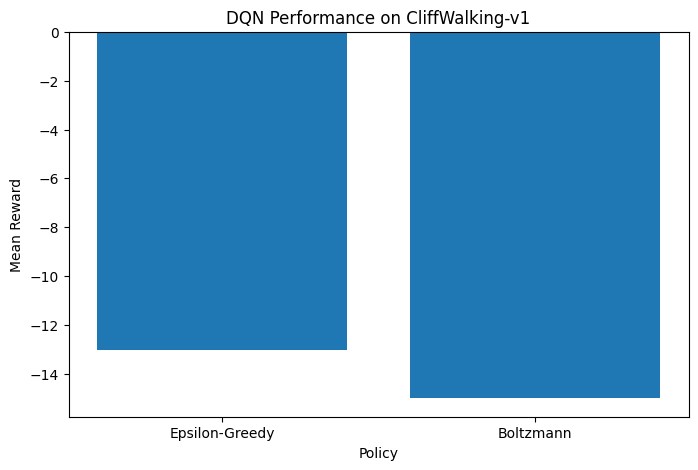

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results["Policy"], results["Mean Reward"])
plt.xlabel("Policy")
plt.ylabel("Mean Reward")
plt.title("DQN Performance on CliffWalking-v1")
plt.show()